Index(['ElapsedTime_s', 'Distance', 'Si29_CPS', 'Mg_ppm_m25', 'Al_ppm_m27',
       'Sc_ppm_m45', 'Ti_ppm_m47', 'Fe_ppm_m57', 'Re_ppm_m185', 'Pt_ppm_m195'],
      dtype='object')
Index(['ElapsedTime_s', 'Distance', 'Si29_CPS', 'Mg_ppm_m25', 'Al_ppm_m27',
       'Sc_ppm_m45', 'Ti_ppm_m47', 'Fe_ppm_m57', 'Re_ppm_m185', 'Pt_ppm_m195'],
      dtype='object')


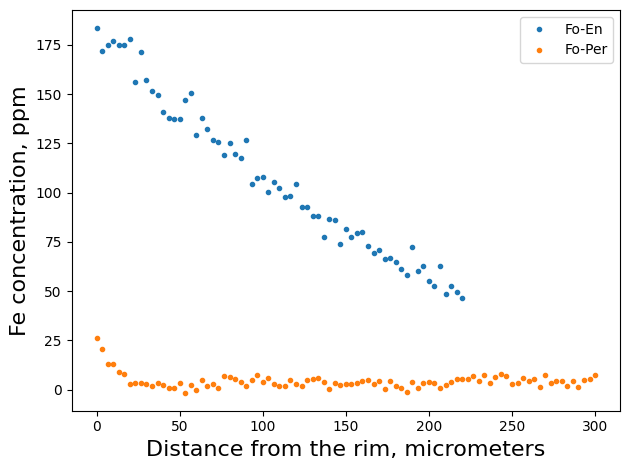

In [1]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)
import pandas as pd
import scipy
from scipy.optimize import curve_fit

from scipy.special import erfc
#
# Loading the data
#
data_1400C_192h_FoEn = pd.read_csv("./data/16C_ICP1_1400C_axisC_192h_FoEn.csv")
print(data_1400C_192h_FoEn.columns)
data_1400C_192h_FoPer = pd.read_csv("./data/16B_ICP2_1400C_axisC_192h_FoPer.csv")
print(data_1400C_192h_FoPer.columns)

#
# The data we want to fit
#
t_exp = 192.0*3600
x_obs_1 = data_1400C_192h_FoEn.Distance.values
y_obs_1 = data_1400C_192h_FoEn.Fe_ppm_m57.values
ese_obs_1 = 6.0*np.ones(len(x_obs_1))

#
# Plotting the data
#
plt.plot(x_obs_1,y_obs_1,".",label="Fo-En")
plt.plot(data_1400C_192h_FoPer.Distance, data_1400C_192h_FoPer.Fe_ppm_m57, ".", label="Fo-Per")
plt.xlabel("Distance from the rim, micrometers",fontsize=16)
plt.ylabel("Fe concentration, ppm",fontsize=16)
plt.legend()
plt.tight_layout()

Now we solve the problem using the methods we know. I start with a global search for a solution using the differential evolution algorithm, then once it founds a good solution, I use `curve_fit` to refine the solution and get access to the covariance matrix.

Optimal values:
[-13.72458457 181.65279121  23.33726848]
Error bars:
[0.06948159 1.84691907 8.28835661]


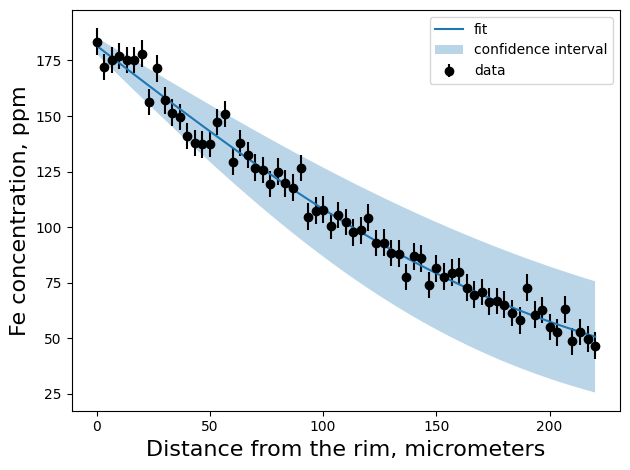

In [2]:
def forward_model(x, D, crim, ccore):
    """This is the foward model: solution in 1D of Fick diffusion
    
    Parameters
    ----------
    x : 1d array
        the distance in microns
    D : float
        the diffusion coefficient, in log10 m2 s-1
    c0 : float
        the concentration at the border
        
    Returns
    -------
    c(x) : array
        the array of the concentrations at x
    """
    t = 192.0*3600 # time is defined here
    return (crim-ccore)*erfc(x*1e-6/(2*np.sqrt(10**D*t))) + ccore

from scipy.optimize import differential_evolution # we import the method here

def least_squares_objective(list_of_parameters, x, y, yerr=1.0):
    """the least square objective function"""
    model_values = forward_model(x, list_of_parameters[0], list_of_parameters[1], list_of_parameters[2])
    criterion = np.sum((y-model_values)**2/yerr**2) # ponderated least squares criterion
    return criterion

# we need to define a search space
# in the form of a list, containing sub-mlists of lower and upper bounds for the parameters
search_space = [[-30., 0.], # D bounds
                [0.0, 200.], #crim
                [0.0, 200.]] #ccore

# the differential_evolution expects that the least_squares_objective
# function takes the parameters as the first argument. 
# Any additional inputs are provided in a tuple via the args argument
# this is pretty standard in scipy
# the minimize() function (actually behind curve_fit) uses the same API
result_LS = differential_evolution(least_squares_objective, # objective function
                                   search_space, # search space (list of [lb, hb] per parameter)
                                   args=(x_obs_1,
                                         y_obs_1,
                                         ese_obs_1))
pini = result_LS.x
popt, pcov = curve_fit(forward_model, x_obs_1, y_obs_1, sigma=ese_obs_1, p0=pini)
perr = np.sqrt(np.diag(pcov))

# model predictions
y_calc = forward_model(x_obs_1, *popt)
# confidence interval (95 %)
y_lower_ci = forward_model(x_obs_1, *popt-2*np.sqrt(np.diag(pcov)))
y_upper_ci = forward_model(x_obs_1, *popt+2*np.sqrt(np.diag(pcov)))

# now a figure representing the data and the fit
plt.figure()
plt.errorbar(x_obs_1, y_obs_1, yerr=ese_obs_1, fmt="ko", label="data")
plt.plot(x_obs_1, forward_model(x_obs_1, *popt), label="fit")
# add a plot of the confidence interval
plt.fill_between(x_obs_1, y_lower_ci, y_upper_ci,
                 alpha=0.3, label="confidence interval")
plt.xlabel("Distance from the rim, micrometers",fontsize=16)
plt.ylabel("Fe concentration, ppm",fontsize=16)
plt.legend()
plt.tight_layout()

# print the optimal values and the error bars
print("Optimal values:")
print(popt)
print("Error bars:")
print(np.sqrt(np.diag(pcov)))

The uncertainty envelop looks weird. Wait, we did not take into account for covariance between the parameters. It actually may be high. We first check for this by plotting the covariance matrix in colors, with the values in each cell.

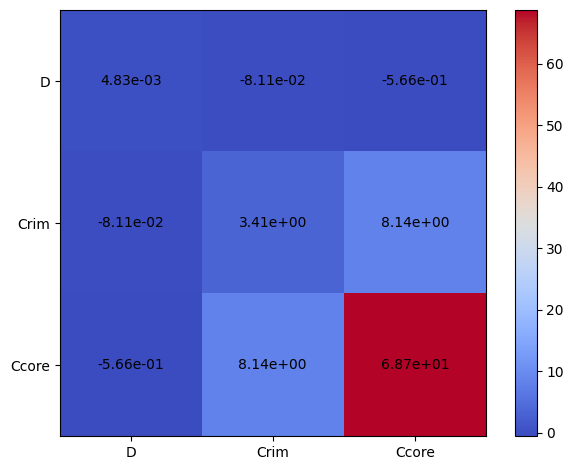

In [3]:
# plot the covariance matrix with color code
plt.figure()
plt.imshow(pcov, cmap="coolwarm")
# add the values in the cells
for i in range(3):
    for j in range(3):
        plt.text(i,j, f"{pcov[i,j]:.2e}", ha="center", va="center", color="black")  
# add labels
plt.xticks([0,1,2], ["D", "Crim", "Ccore"])
plt.yticks([0,1,2], ["D", "Crim", "Ccore"])
plt.colorbar()
plt.tight_layout()

OK, we observe an important covariance between parameters. We cannot neglect it. We need to take it into account in the error bars. We can do that by using the covariance matrix.

The covariance matrix is a square matrix of the same size as the number of parameters. The diagonal contains the variance of each parameter, and the off-diagonal elements contain the covariance between the parameters. The covariance matrix is the inverse of the Hessian matrix of the least squares objective function. The Hessian matrix is the matrix of second derivatives of the least squares objective function. It is a measure of the curvature of the least squares objective function around the optimal values of the parameters.

You can use a formula to propagate the errors on and the covariances between the parameters when calculating the confidence intervals for the values of Y. It involves calculating derivatives, and could become quite complex. Fortunately, libraries such as `uncertainties` do that for you, see the docs [here](https://pythonhosted.org/uncertainties/user_guide.html). I advise using them. Let's use `uncertainties` below:

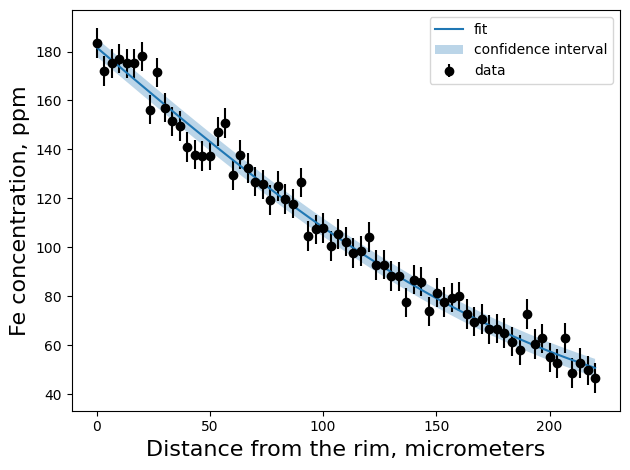

In [4]:
import uncertainties
from uncertainties import unumpy

# we create a list of uncertainties
popt_un = uncertainties.correlated_values(popt, pcov)

# we can now use the forward model with uncertainties
y = forward_model(x_obs_1, *unumpy.nominal_values(popt_un))
yerr = forward_model(x_obs_1, *unumpy.std_devs(popt_un)*2) # at 2 sigma level

plt.figure()
plt.errorbar(x_obs_1, y_obs_1, yerr=ese_obs_1, fmt="ko", label="data")
plt.plot(x_obs_1, y, label="fit")
plt.fill_between(x_obs_1, y-yerr, y+yerr, alpha=0.3, label="confidence interval")
plt.xlabel("Distance from the rim, micrometers",fontsize=16)
plt.ylabel("Fe concentration, ppm",fontsize=16)
plt.legend()
plt.tight_layout()

Our error bars look small. We can check if they are OK. Indeed, if they are, 95% of the data points should fall within the 2-sigma error bars. Let's check this.

In [5]:
# check if 95% of the data points fall within the 2 sigma interval
mask = (y_obs_1 > y-2*yerr) & (y_obs_1 < y+2*yerr)
print("Fraction of data points within 2 sigma:", np.sum(mask)/len(mask))


Fraction of data points within 2 sigma: 0.8208955223880597


Ah. Our confidence intervals are a little bit too small. Maybe our estimates on the error affecting the data points is bad. Maybe the optimization method is not appropriate... In any cases, something is not going well... Maybe we need to calculate the error bars in a different way. This is where we will use the bootstrap method.